### 1. DATA UNDERSTANDING
**Goal**: Explore dataset structure, data quality, and key characteristics

In [ ]:
# Set working directory
import local_config
from local_config import *
import os
os.chdir(directory_path)


# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', None)

# ---------------------------------------------------------
# Load dataset
# ---------------------------------------------------------
df = pd.read_excel('data/raw/OnlineRetail.xlsx')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
# ---------------------------------------------------------
# Dataset overview
# ---------------------------------------------------------

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


### Initial observations:
* Dataset contains **541,909 rows and 8 columns**
* `CustomerID` contains missing values
* `CustomerID` is float → should be categorical / integer-like

In [3]:
# ---------------------------------------------------------
# Missing values analysis
# ---------------------------------------------------------

missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

CustomerID     135080
Description      1454
StockCode           0
InvoiceNo           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

### Observations:
* Significant number of missing values in `CustomerID`
* These records may represent **guest checkouts** or **unidentified customers**
* Decision on handling will be made during data understanding stage

In [4]:
# ---------------------------------------------------------
# Basic statistics
# ---------------------------------------------------------

df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### Observations:
* `Quantity` and `UnitPrice` contain:
    * Negative values
    * Extreme outliers
* Indicates:
    * Returns (negative quantity)
    * Possible data entry errors or bulk transactions

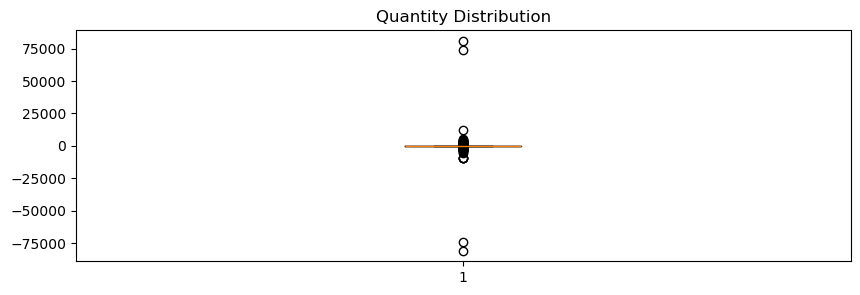

(2, 8)

In [5]:
# ---------------------------------------------------------
# Outliers exploration
# ---------------------------------------------------------

# Quantity distribution
plt.figure(figsize=(10, 3))
plt.boxplot(df['Quantity'])
plt.title('Quantity Distribution')
plt.show()

# Extreme values
df[df['Quantity'] > 50000].shape

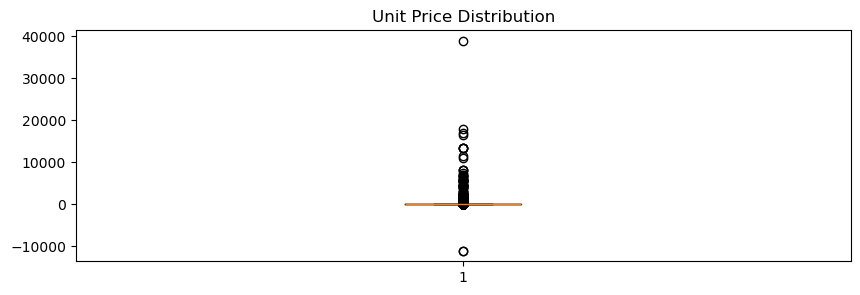

(1, 8)

In [6]:
# UnitPrice distribution
plt.figure(figsize=(10, 3))
plt.boxplot(df['UnitPrice'])
plt.title('Unit Price Distribution')
plt.show()

df[df['UnitPrice'] > 30000].shape

### Observations:
* Presence of extreme values:
    * Bulk purchases
    * Potential data errors
* Will require treatment (capping / filtering) later

In [7]:
# ---------------------------------------------------------
# Duplicates
# ---------------------------------------------------------

df.duplicated().sum()

np.int64(5268)

### Observations:
* Duplicate rows exist
* Need investigation before removal:
    * True duplicates?
    * Or repeated items within same order?

In [8]:
# ---------------------------------------------------------
# Returns analysis
# ---------------------------------------------------------

# Negative quantity (returns)
negative_qty = df[df['Quantity'] < 0]
negative_qty.shape

(10624, 8)

In [9]:
# Negative price (rare)
negative_price = df[df['UnitPrice'] < 0]
negative_price.shape

(2, 8)

In [10]:
# Cancelled orders (InvoiceNo starting with 'C')
df[df['InvoiceNo'].str.startswith('C', na=False)].shape

(9288, 8)

### Observations:
* Negative `Quantity` = product returns
* 'C' in `InvoiceNo` = cancelled orders
* Negative `UnitPrice` is rare → likely data issues or adjustments
* Returns and cancellations should be handled carefully in cohort analysis

In [11]:
# ---------------------------------------------------------
# Key entities exploration
# ---------------------------------------------------------

# Date range 
df['InvoiceDate'].min(), df['InvoiceDate'].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [12]:
# Unique customers
df['CustomerID'].nunique()

4372

In [13]:
# Unique invoices
df['InvoiceNo'].nunique()

25900

In [14]:
# Unique countries
df['Country'].nunique()
df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

### Observations:
* Dataset contains multiple countries → potential segmentation opportunity
* Number of transactions >> number of invoices:
    * Each invoice contains multiple products
    * Dataset is transaction-level (line-item level), not order-level